In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

In [27]:
df = pd.read_csv("car_evaluation.csv")

In [28]:
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [29]:
df.shape

(1727, 7)

In [30]:
df.describe()

,vhigh,vhigh.1,2,2.1,small,low,unacc
count,1727,1727,1727,1727,1727,1727,1727
unique,4,4,4,3,3,3,4
top,high,high,3,4,med,med,unacc
freq,432,432,432,576,576,576,1209


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vhigh    1727 non-null   object
 1   vhigh.1  1727 non-null   object
 2   2        1727 non-null   object
 3   2.1      1727 non-null   object
 4   small    1727 non-null   object
 5   low      1727 non-null   object
 6   unacc    1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [32]:
df.columns

Index(['vhigh', 'vhigh.1', '2', '2.1', 'small', 'low', 'unacc'], dtype='object')

In [33]:
df.columns = ['buying','maintance','doors','persons','space','safety','class']

In [34]:
df.columns

Index(['buying', 'maintance', 'doors', 'persons', 'space', 'safety', 'class'], dtype='object')

In [35]:
df.isnull().sum()

buying       0
maintance    0
doors        0
persons      0
space        0
safety       0
class        0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

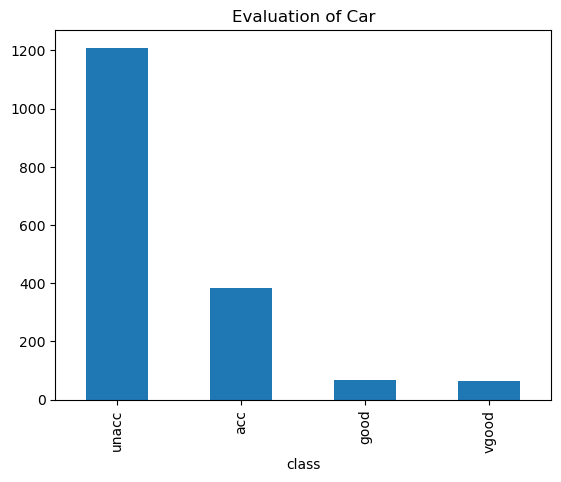

In [37]:
df['class'].value_counts().plot(kind='bar')
plt.title("Evaluation of Car")
plt.show()

In [38]:
print(df['class'].value_counts())

class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


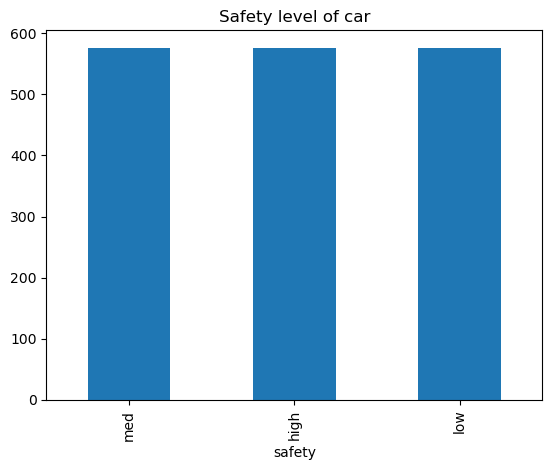

In [39]:
df['safety'].value_counts().plot(kind='bar')
plt.title("Safety level of car")
plt.show()

In [40]:
print(df['safety'].value_counts())

safety
med     576
high    576
low     575
Name: count, dtype: int64


In [41]:
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [42]:
df = pd.get_dummies(df, columns=['buying','maintance','doors','persons','space','safety'])

In [43]:
print(df.head())


   class  buying_high  buying_low  buying_med  buying_vhigh  maintance_high  \
0      2        False       False       False          True           False   
1      2        False       False       False          True           False   
2      2        False       False       False          True           False   
3      2        False       False       False          True           False   
4      2        False       False       False          True           False   

   maintance_low  maintance_med  maintance_vhigh  doors_2  ...  doors_5more  \
0          False          False             True     True  ...        False   
1          False          False             True     True  ...        False   
2          False          False             True     True  ...        False   
3          False          False             True     True  ...        False   
4          False          False             True     True  ...        False   

   persons_2  persons_4  persons_more  space_big  

In [44]:
X = df.drop('class', axis=1)
y = df['class']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)  
print(y_train.shape)          
print(X_test.shape)           
print(y_test.shape) 

(1381, 21)
(1381,)
(346, 21)
(346,)


In [46]:
scaler=StandardScaler()
X_train =scaler.fit_transform(X_train)
X_test =scaler.transform(X_test)

In [48]:
log_r = LogisticRegression()
log_r.fit(X_train, y_train)

LogisticRegression()

In [49]:
y_pred = log_r.predict(X_test)

In [51]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:",confusion_matrix(y_test, y_pred))

Accuracy: 0.9219653179190751
Confusion Matrix: [[ 64   5   7   1]
 [  1   8   0   6]
 [  6   0 231   0]
 [  1   0   0  16]]


In [56]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [57]:
y_pred = dt.predict(X_test)

In [58]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:",confusion_matrix(y_test, y_pred))

Accuracy: 0.9595375722543352
Confusion Matrix: [[ 71   0   4   2]
 [  0  12   0   3]
 [  2   0 235   0]
 [  1   2   0  14]]


In [61]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [63]:
y_pred = rf.predict(X_test)

In [64]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:",confusion_matrix(y_test, y_pred))

Accuracy: 0.953757225433526
Confusion Matrix: [[ 73   2   1   1]
 [  3   8   0   4]
 [  1   0 236   0]
 [  4   0   0  13]]


In [65]:
model_rbf = SVC(kernel='rbf')
model_rbf.fit(X_train, y_train)

SVC()

In [66]:
y_pred = model_rbf.predict(X_test)

In [67]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9479768786127167


In [68]:
model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)

SVC(kernel='linear')

In [69]:
y_pred = model_linear.predict(X_test)

In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9248554913294798


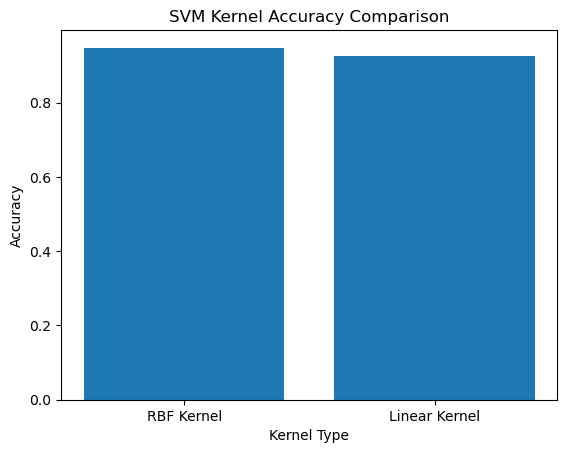

In [71]:
acc_rbf = model_rbf.score(X_test, y_test)
acc_linear = model_linear.score(X_test, y_test)

models = ['RBF Kernel','Linear Kernel']
accuracy = [acc_rbf, acc_linear]

plt.bar(models, accuracy)
plt.title("SVM Kernel Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Kernel Type")
plt.show()

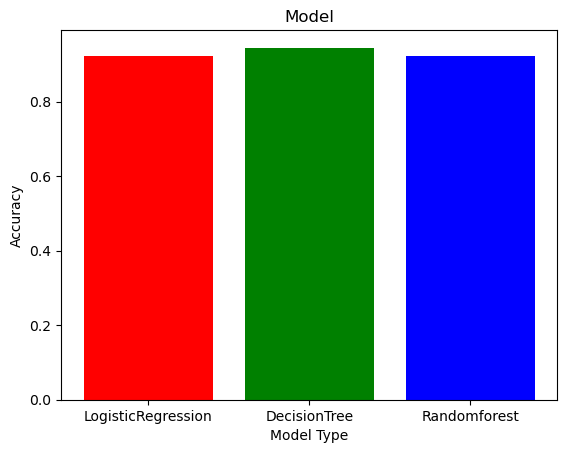

In [80]:
acc_log_r = log_r.score(X_test, y_test)
acc_dt = dt.score(X_test, y_test)
acc_rf = log_r.score(X_test, y_test)

models = ['LogisticRegression','DecisionTree','Randomforest']
accuracy = [acc_log_r, acc_dt, acc_rf]

plt.bar(models, accuracy, color=['r','g','b'])
plt.title("Model")
plt.ylabel("Accuracy")
plt.xlabel("Model Type")
plt.show()